In [1]:
# This code works in Python 3.10.6
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import torch_geometric.transforms as T
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
from torch_geometric.datasets.dblp import DBLP
import os
import os.path as osp

### DBLP

In [3]:
dataset = DBLP(root='./dblp_data', transform=T.Constant(node_types='conference'))
data = dataset[0]
data

HeteroData(
  author={
    x=[4057, 334],
    y=[4057],
    train_mask=[4057],
    val_mask=[4057],
    test_mask=[4057],
  },
  paper={ x=[14328, 4231] },
  term={ x=[7723, 50] },
  conference={
    num_nodes=20,
    x=[20, 1],
  },
  (author, to, paper)={ edge_index=[2, 19645] },
  (paper, to, author)={ edge_index=[2, 19645] },
  (paper, to, term)={ edge_index=[2, 85810] },
  (paper, to, conference)={ edge_index=[2, 14328] },
  (term, to, paper)={ edge_index=[2, 85810] },
  (conference, to, paper)={ edge_index=[2, 14328] }
)

In [4]:
author = data['author'].x.tolist()
author_df = pd.DataFrame(author)
author_df['class'] = data['author'].y.tolist()

In [5]:
def get_selected_features(X):

    col_sum = X.sum(axis=0)
    sorted_colsum = sorted(col_sum, reverse=True)
    colsum_df = pd.DataFrame(col_sum)
    
    sorted_colsum = sorted(col_sum, reverse=True)
    index_list = list(np.ravel(colsum_df[colsum_df[0].isin(sorted_colsum)].index))[:50]
    
    imp_feat = X[index_list]
    #imp_feat = imp_feat.drop(imp_feat[imp_feat.sum(axis=1) == 0.0].index)


    return imp_feat

### Bag-of-Words features of Author node

In [6]:
author_class0 = author_df[author_df['class'] == 0].drop(['class'], axis = 1)
class0 = get_selected_features(author_class0)
cols = [i for i in range(0,len(class0.columns))][:50]
class0.columns = cols
class0

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4053,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4054,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
author_class1 = author_df[author_df['class'] == 1].drop(['class'], axis = 1)
class1 = get_selected_features(author_class1)
cols = [i for i in range(0,len(class1.columns))][:50]
class1.columns = cols
class1

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3686,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3821,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
author_class2 = author_df[author_df['class'] == 2].drop(['class'], axis = 1)
class2 = get_selected_features(author_class2)
cols = [i for i in range(0,len(class2.columns))][:50]
class2.columns = cols
class2

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3499,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3515,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
author_class3 = author_df[author_df['class'] == 3].drop(['class'], axis = 1)
class3 = get_selected_features(author_class3)
cols = [i for i in range(0,len(class3.columns))][:50]
class3.columns = cols
class3

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3886,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3887,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
def sample_features(model,node_type, n_samples):

    smpls = model.sample(n_samples)
    print("no. of class {} node samples - {}".format(node_type, n_samples))
    return smpls[0]

In [11]:
def fit_sample_gm(df_class, node_type, n_samples):
    #fit
    model = GaussianMixture(n_components=1, covariance_type='full', random_state = 0)
    model.fit(df_class)
    #print("Mean for nodetype", node_type,model.means_)
    #sample
    smpls = sample_features(model, node_type, n_samples)
    new_features_dict[node_type] = smpls

In [12]:
def feature_selection(df):
    col_sum = df.sum(axis=0)
    sorted_colsum = sorted(col_sum, reverse=True)

    index_list = []
    for i in sorted_colsum[:1]:
        index_list.append(list(col_sum).index(i))
    imp_feat = df[index_list].reset_index(drop=True)
    return imp_feat

In [13]:
def convert_to_dicrete(df):
    return df.applymap(lambda x: 0.0 if x<0.5 else 1.0)

In [14]:
plt.rcParams.update({'axes.ymargin': 0.2})

In [15]:
def compare_plot_real_syn(df):
    df_new = df.apply(pd.value_counts).T
    print(df_new)
    ax=df_new.plot.bar(width=0.4,figsize=(7,7))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
    for i in ax.containers:
        ax.bar_label(i,fontsize=20)
    
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize="20", loc ="lower center")
    plt.ylabel('no. of samples',fontsize=20)   
    plt.tight_layout()
    plt.show()
    plt.clf() 

In [16]:
def cosine_sim(original,sampled):
    return cosine_similarity(np.array(original), np.array(sampled))

### Fit Gaussian Mixture Models to 4 Author node classes

In [17]:
new_features_dict = {}

In [18]:
fit_sample_gm(class0, 'author0', class0.shape[0])
fit_sample_gm(class1, 'author1', class1.shape[0])
fit_sample_gm(class2, 'author2', class2.shape[0])
fit_sample_gm(class3, 'author3', class3.shape[0])

no. of class author0 node samples - 1197
no. of class author1 node samples - 745
no. of class author2 node samples - 1109
no. of class author3 node samples - 1006


### Continuous features sampled using Gaussian Mixure Models

In [19]:
sampled0  = pd.DataFrame(new_features_dict['author0'])
sampled0.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.049569,-0.789723,-0.043755,0.017672,0.039362,0.150528,-0.031423,-0.104448,0.033100,0.083177,...,-0.021443,-0.130688,-0.038929,0.059347,0.072080,-0.109225,-0.042022,0.182243,0.410312,-0.080913
1,-0.165639,0.507968,0.031246,0.035837,0.141083,-0.179132,0.002888,0.000957,0.334805,0.148273,...,-0.188805,0.022418,0.116231,-0.018401,0.208151,0.049312,-0.002353,0.025346,0.191105,-0.007052
2,0.194851,-0.034049,0.015888,0.073874,-0.213187,0.184640,0.014456,-0.136596,-0.190292,0.044098,...,0.018068,0.135113,-0.076270,-0.139562,-0.673982,0.090297,0.200382,0.081818,-0.143260,-0.020578
3,0.205636,0.407007,-0.030268,-0.047486,-0.145136,0.113588,-0.016201,-0.100966,0.014610,0.389427,...,-0.038368,-0.042830,0.124958,-0.122445,0.231639,-0.034068,0.022702,0.140390,0.041605,0.075952
4,0.005423,-0.316929,-0.002469,-0.039130,0.244839,0.420302,-0.064616,-0.053883,-0.017419,0.029655,...,0.082465,0.118181,0.059216,-0.066414,0.181399,0.148946,-0.039000,-0.056937,-0.060126,0.056099


In [20]:
sampled1  = pd.DataFrame(new_features_dict['author1'])
sampled1.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.202598,0.208676,-0.126925,-0.166029,0.053422,0.219118,-0.006554,-0.103309,-0.216368,-0.472951,...,0.098518,-0.021823,-0.089146,0.296124,0.297454,-0.111177,-0.153008,-0.068343,-0.000879,-0.166883
1,0.268290,0.094503,-0.073542,0.010156,0.006336,-0.002423,-0.202823,-0.057691,-0.067701,0.211179,...,-0.132322,0.065103,-0.093183,0.052610,-0.184468,0.018034,0.135211,-0.184778,-0.050186,-0.052883
2,-0.174213,0.313891,-0.114964,-0.089407,-0.072286,0.296021,-0.075281,-0.059311,0.152407,-0.049690,...,0.207624,-0.069779,-0.154962,-0.001860,0.258610,0.028505,0.020816,0.118751,0.161709,0.154673
3,0.011320,-0.221098,0.047115,0.084479,-0.185250,0.322504,0.008374,0.087442,0.019112,-0.016954,...,-0.026175,0.198214,0.069641,-0.057870,0.028042,-0.093297,0.161674,-0.127671,0.139403,0.023045
4,-0.014300,0.148679,0.054283,-0.106588,0.076330,0.257606,-0.035440,0.121787,0.144576,0.364445,...,0.109603,-0.152710,0.173960,0.194042,-0.232462,0.059865,0.011439,0.040242,0.102612,0.060403


In [21]:
sampled2  = pd.DataFrame(new_features_dict['author2'])
sampled2.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.409299,-0.043287,0.201547,0.409088,-0.044000,-0.169092,0.313775,0.188761,0.035937,-0.302298,...,0.056362,0.139255,0.199468,0.073512,0.155408,-0.201543,0.165945,-0.219997,0.248606,-0.104407
1,0.271911,0.010565,-0.012020,0.018211,0.019137,0.104677,-0.138781,-0.064684,0.049018,0.319564,...,0.057766,0.007715,-0.190265,-0.090209,0.044374,0.260942,0.082768,0.006898,0.385797,-0.099961
2,0.000152,-0.021688,0.158217,-0.149402,-0.088083,-0.178851,-0.314488,-0.354725,-0.063456,0.164241,...,0.223735,0.068197,0.165029,-0.119306,0.161821,-0.345079,-0.065535,-0.170064,-0.325829,0.030354
3,0.062964,0.009006,0.489588,-0.064488,-0.118540,-0.075666,-0.056893,0.204765,0.070891,-0.188776,...,0.070611,-0.142564,-0.358142,0.074220,0.027958,0.359671,-0.020234,0.315011,-0.020210,-0.171919
4,-0.052723,-0.103953,0.064865,0.157444,0.114713,0.182222,0.104941,0.381253,0.184209,-0.118954,...,-0.038438,0.026071,0.001192,-0.059300,0.269459,0.206349,-0.205618,-0.134084,-0.141224,0.210110


In [22]:
sampled3  = pd.DataFrame(new_features_dict['author3'])
sampled3.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.121422,-0.111860,0.042783,-0.016637,-0.381685,0.261054,-0.029686,0.007482,0.052267,-0.139526,...,0.010418,0.310766,-0.148005,0.025767,0.069452,-0.099933,0.059987,0.113072,-0.163950,-0.221527
1,-0.047002,-0.095135,0.016106,0.017006,-0.047804,-0.160419,-0.082032,-0.012039,0.117735,0.026120,...,0.220537,-0.042378,0.198148,0.107242,0.074714,-0.002860,0.066576,0.082991,-0.006510,-0.017234
2,-0.198645,0.262532,-0.029184,0.133437,0.147870,-0.018151,-0.054922,0.016545,-0.015882,0.123286,...,-0.397579,-0.115441,-0.190686,-0.155573,-0.212922,-0.057953,-0.016300,-0.091334,-0.005279,0.242706
3,0.151185,-0.142799,0.222486,0.001320,-0.048644,0.005262,-0.034136,-0.040528,0.002476,-0.011530,...,0.244400,0.059844,-0.100997,0.103648,0.114343,-0.030445,-0.003299,0.199679,0.085045,0.418834
4,0.400603,-0.009367,0.071516,-0.050345,0.062349,0.184755,-0.037291,0.046346,0.102882,-0.043217,...,0.154901,0.112198,0.055854,0.286433,-0.011318,-0.018146,-0.173297,-0.041252,-0.004038,0.115768


### Sampled continuous features are converted to discrete using a threshold

In [23]:
authorclass0_sampled = convert_to_dicrete(pd.DataFrame(new_features_dict['author0']))
authorclass0_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
authorclass1_sampled = convert_to_dicrete(pd.DataFrame(new_features_dict['author1']))
authorclass1_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
authorclass2_sampled = convert_to_dicrete(pd.DataFrame(new_features_dict['author2']))
authorclass2_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
authorclass3_sampled = convert_to_dicrete(pd.DataFrame(new_features_dict['author3']))
authorclass3_sampled.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Pairwise cosine similarity of all features for real and synthetic distributions

Author class 0

In [27]:
cosine_sim(class0,authorclass0_sampled)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.70710678, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.5       , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [28]:
sns.set(font_scale=1.4)

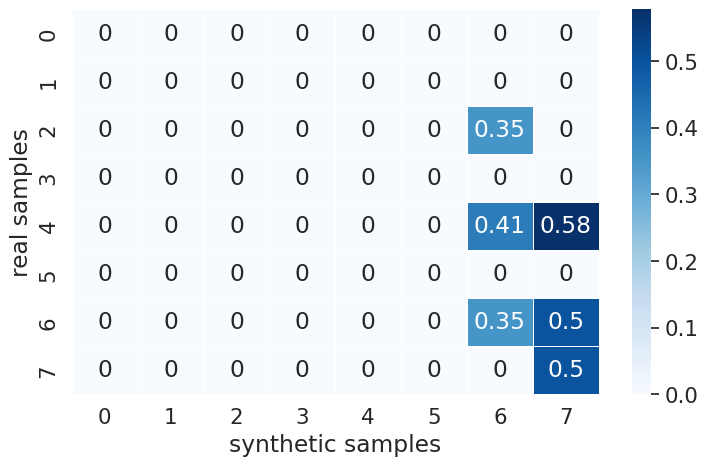

In [29]:
fig, ax = plt.subplots(figsize=(8.5,5)) 
sns.heatmap(cosine_sim(class0.iloc[:8],authorclass0_sampled[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [30]:
avg_cossim_class0 = np.mean(cosine_sim(class0,authorclass0_sampled))
avg_cossim_class0

0.051291793823747815

Author class 1

In [31]:
cosine_sim(class1,authorclass1_sampled)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.57735027, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.33333333, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.57735027, 0.        ,
        0.        ]])

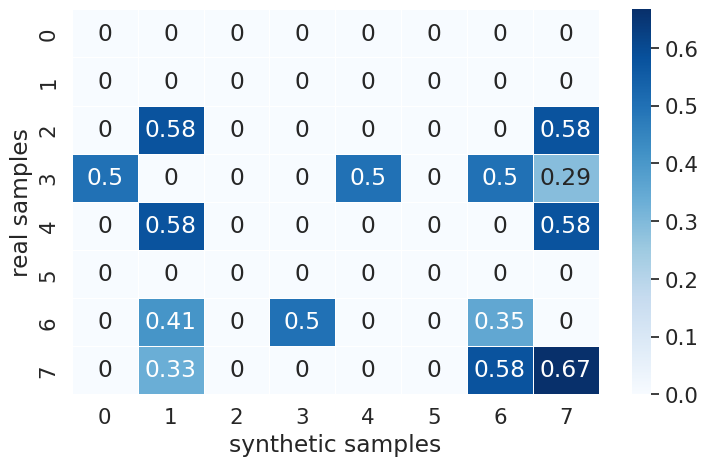

In [32]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(class1.iloc[:8],authorclass1_sampled[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [33]:
avg_cossim_class1 = np.mean(cosine_sim(class1,authorclass1_sampled))
avg_cossim_class1

0.10122005327901884

Author class 2

In [34]:
cosine_sim(class2,authorclass2_sampled)

array([[0.        , 0.        , 0.57735027, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.31622777, 0.        ,
        0.        ],
       [0.        , 0.33333333, 0.33333333, ..., 0.23570226, 0.        ,
        0.23570226],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.70710678, 0.        , ..., 0.5       , 0.        ,
        0.5       ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

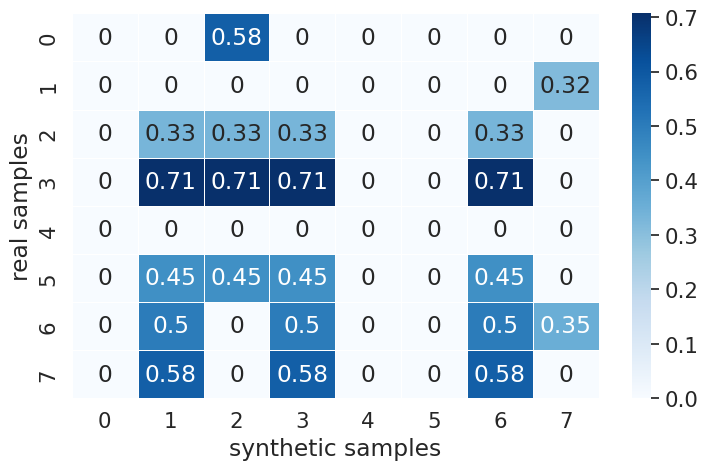

In [35]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(class2.iloc[:8],authorclass2_sampled[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [36]:
avg_cossim_class2 = np.mean(cosine_sim(class2,authorclass2_sampled))
avg_cossim_class2

0.061289397994346316

Author class 3

In [37]:
cosine_sim(class3,authorclass3_sampled)

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.70710678,
        0.        ],
       [0.40824829, 0.40824829, 0.40824829, ..., 0.        , 0.28867513,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

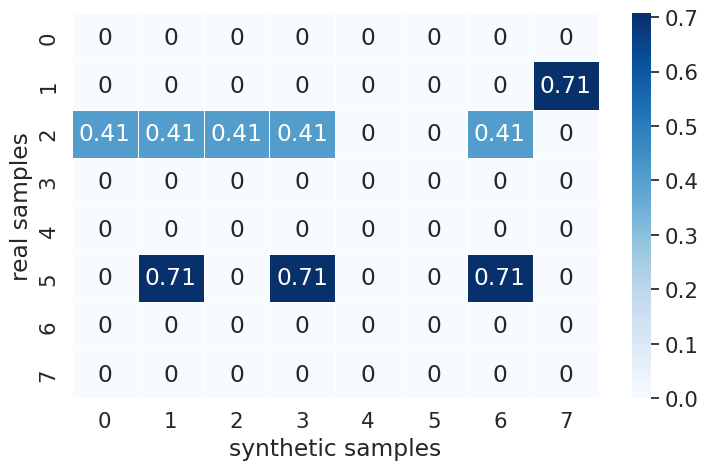

In [38]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(class3.iloc[:8],authorclass3_sampled[:8]), 
            xticklabels = 1, yticklabels = 1, annot=True, cmap='Blues', linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [39]:
avg_cossim_class3 = np.mean(cosine_sim(class3,authorclass3_sampled))
avg_cossim_class3

0.06025075775679957

In [40]:
(avg_cossim_class0 + avg_cossim_class1 +avg_cossim_class2 + avg_cossim_class3)/4

0.06851300071347814